# Этап 2: Разработка моделей

Этот ноутбук содержит разработку и обучение моделей:
- Предобучение модели DeepFM+SVD++
- Создание среды EducationalEnvironment
- Разработка агента Dueling DQN
- Настройка пайплайна обучения

> **Обновление API.** Обучение DeepFM+SVD++ и Dueling DQN теперь лучше
> запускать через `src.api`:
>
> ```python
> from src import api
> config = api.build_config("itmrec", yaml_path="configs/itmrec.yaml")
> run = api.train_static("itmrec", config=config)
> api.train_dqn("itmrec", config=config, deepfm_checkpoint=run["history"]["best_checkpoint"])
> ```
>
> Ячейки ниже сохранены для пошагового построения моделей (разведочный режим).
> Аналог для OULAD — ноутбук `05_oulad_model.ipynb`.

In [4]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import warnings
warnings.filterwarnings('ignore')

# Импорт модулей проекта
import sys
sys.path.append('../')

from src.data.loaders import load_all_data
from src.data.dataset import ITMDataset
from src.models.deepfm_svdpp import DeepFMSVDPlusPlus
from src.models.dueling_dqn import DuelingDQN
from src.environment.educational_env import EducationalEnvironment
from src.training.replay_buffer import PrioritizedReplayBuffer
from src.training.trainer import DQNTrainer
from src.training.config import TRAIN_CONFIG, DEEPFM_CONFIG, REPLAY_BUFFER_CONFIG
from src.utils.helpers import set_seed

# Установка seed для воспроизводимости
set_seed(42)

# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

Используется устройство: cpu


## 1. Загрузка и подготовка данных

In [5]:
# Загрузка данных (если уже обработаны)
# Или загрузка с Kaggle если нужно
import os
if os.path.exists('../data/processed/ratings_processed.csv'):
    print("Загрузка обработанных данных...")
    ratings = pd.read_csv('../data/processed/ratings_processed.csv')
    users = pd.read_csv('../data/processed/users_processed.csv')
    items = pd.read_csv('../data/processed/items_processed.csv')
else:
    print("Загрузка данных с Kaggle...")
    from src.data.loaders import download_kaggle_dataset
    data_path = download_kaggle_dataset("irecsys/itmrec", "../data/raw")
    data = load_all_data(data_path)
    ratings = data['ratings']
    users = data['users']
    items = data['items']

# Создание датасета
print("\nСоздание ITMDataset...")
dataset = ITMDataset(ratings, users, items)

# Разделение на train/val/test
train_loader, val_loader, test_loader = dataset.train_test_split(
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    batch_size=DEEPFM_CONFIG['batch_size'],
    shuffle=True,
    random_state=42
)

Загрузка обработанных данных...

Создание ITMDataset...
Датасет инициализирован:
  Пользователей: 454
  Предметов: 70
  Классов: 3
  Семестров: 2
  Периодов COVID: 3
  Записей рейтингов: 5230
Разделение датасета:
  Train: 3660 (70.0%)
  Val: 784 (15.0%)
  Test: 786 (15.0%)


## 2. Предобучение DeepFM+SVD++

In [6]:
print("\n" + "="*50)
print("1. ПРЕДОБУЧЕНИЕ DeepFM-SVD++")
print("="*50)

# Создание модели
model = DeepFMSVDPlusPlus(
    n_users=dataset.n_users,
    n_items=dataset.n_items,
    n_classes=dataset.n_classes,
    n_semesters=dataset.n_semesters,
    n_lockdowns=dataset.n_lockdowns,
    device=device,
    embedding_dim=DEEPFM_CONFIG['embedding_dim'],
    hidden_dims=DEEPFM_CONFIG['hidden_dims'],
    dropout_rate=DEEPFM_CONFIG['dropout']
)

print(f"Модель создана на {device}")
print(f"  Параметров: {sum(p.numel() for p in model.parameters()):,}")

# Оптимизатор и функция потерь
optimizer = optim.Adam(model.parameters(), lr=DEEPFM_CONFIG['lr'], 
                       weight_decay=DEEPFM_CONFIG.get('weight_decay', 1e-5))
criterion = nn.MSELoss()

# Обучение
n_epochs = DEEPFM_CONFIG['n_epochs']
best_val_loss = float('inf')

print(f"\nОбучение на {device}...")
for epoch in range(n_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for features, targets in train_loader:
        for key in features:
            features[key] = features[key].to(device)
        targets = targets.to(device)
        
        outputs = model(
            features['user_id'].squeeze(),
            features['item_id'].squeeze(),
            features['class'].squeeze(),
            features['semester'].squeeze(),
            features['lockdown'].squeeze()
        )
        
        loss = (criterion(outputs['rating'], targets[:, 0]) +
               criterion(outputs['app'], targets[:, 1]) +
               criterion(outputs['data'], targets[:, 2]) +
               criterion(outputs['ease'], targets[:, 3])) / 4.0
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in val_loader:
            for key in features:
                features[key] = features[key].to(device)
            targets = targets.to(device)
            
            outputs = model(
                features['user_id'].squeeze(),
                features['item_id'].squeeze(),
                features['class'].squeeze(),
                features['semester'].squeeze(),
                features['lockdown'].squeeze()
            )
            
            loss = (criterion(outputs['rating'], targets[:, 0]) +
                   criterion(outputs['app'], targets[:, 1]) +
                   criterion(outputs['data'], targets[:, 2]) +
                   criterion(outputs['ease'], targets[:, 3])) / 4.0
            val_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    print(f"Epoch {epoch+1}/{n_epochs}")
    print(f"  Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    
    # Сохранение лучшей модели
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        os.makedirs('../data/models', exist_ok=True)
        torch.save({
            'model_state_dict': model.state_dict(),
            'user_encoder': dataset.user_encoder,
            'item_encoder': dataset.item_encoder,
            'class_encoder': dataset.class_encoder,
            'semester_encoder': dataset.semester_encoder,
            'lockdown_encoder': dataset.lockdown_encoder,
            'rating_scaler': dataset.rating_scaler
        }, '../data/models/deepfm_svdplusplus_best.pth')
        print("  ✓ Сохранена лучшая модель")

print("\n" + "="*50)
print("Предобучение DeepFM-SVD++ завершено!")
print(f"Лучшая validation loss: {best_val_loss:.4f}")


1. ПРЕДОБУЧЕНИЕ DeepFM-SVD++
Модель создана на cpu
  Параметров: 63,665

Обучение на cpu...
Epoch 1/50
  Train Loss: 0.1207, Val Loss: 0.0946
  ✓ Сохранена лучшая модель
Epoch 2/50
  Train Loss: 0.0918, Val Loss: 0.0795
  ✓ Сохранена лучшая модель
Epoch 3/50
  Train Loss: 0.0830, Val Loss: 0.0747
  ✓ Сохранена лучшая модель
Epoch 4/50
  Train Loss: 0.0790, Val Loss: 0.0715
  ✓ Сохранена лучшая модель
Epoch 5/50
  Train Loss: 0.0747, Val Loss: 0.0699
  ✓ Сохранена лучшая модель
Epoch 6/50
  Train Loss: 0.0715, Val Loss: 0.0697
  ✓ Сохранена лучшая модель
Epoch 7/50
  Train Loss: 0.0687, Val Loss: 0.0706
Epoch 8/50
  Train Loss: 0.0643, Val Loss: 0.0709
Epoch 9/50
  Train Loss: 0.0628, Val Loss: 0.0713
Epoch 10/50
  Train Loss: 0.0608, Val Loss: 0.0710
Epoch 11/50
  Train Loss: 0.0584, Val Loss: 0.0704
Epoch 12/50
  Train Loss: 0.0570, Val Loss: 0.0725
Epoch 13/50
  Train Loss: 0.0558, Val Loss: 0.0732
Epoch 14/50
  Train Loss: 0.0551, Val Loss: 0.0741
Epoch 15/50
  Train Loss: 0.0533, 

## 3. Создание среды EducationalEnvironment

In [7]:
print("\n" + "="*50)
print("2. КОДИРОВАНИЕ СИМУЛЯТОРА ОБРАЗОВАТЕЛЬНОЙ СРЕДЫ")
print("="*50)

# Создание среды
env = EducationalEnvironment(ratings, users, items, model, dataset)

# Тест среды
print("\nТестирование среды...")
state = env.reset()
print(f"  Размерность состояния: {len(state)}")
print(f"  Размерность действия: {env.dataset.n_items}")

# Тестовый шаг
action = np.random.randint(0, env.dataset.n_items)
next_state, reward, done, info = env.step(action)
print(f"  Тестовый шаг: action={action}, reward={reward:.3f}, done={done}")
print(f"  Размерность следующего состояния: {len(next_state)}")


2. КОДИРОВАНИЕ СИМУЛЯТОРА ОБРАЗОВАТЕЛЬНОЙ СРЕДЫ
Инициализация кэшей...
Кэши инициализированы: 454 пользователей, 70 предметов

Тестирование среды...
Эпизод начат: User 158, Context {'class': 0, 'semester': 0, 'lockdown': 2}
  Размерность состояния: 65
  Размерность действия: 70
  Тестовый шаг: action=34, reward=0.771, done=False
  Размерность следующего состояния: 65


## 4. Создание Dueling DQN агента

In [8]:
print("\n" + "="*50)
print("3. ИМПЛЕМЕНТАЦИЯ DUELING DQN АРХИТЕКТУРЫ")
print("="*50)

# Размерности
state_dim = 65  # Из проектирования архитектуры
action_dim = dataset.n_items  # Количество тем проектов

# Создание сети
dqn_agent = DuelingDQN(
    state_dim, 
    action_dim, 
    hidden_dims=[256, 128, 64], 
    device=device
)

print(f"Архитектура агента:")
print(f"  Вход: {state_dim} измерений")
print(f"  Выход: {action_dim} действий")
print(f"  Параметры: {sum(p.numel() for p in dqn_agent.parameters()):,}")

# Тест forward pass
test_state = np.random.randn(state_dim)
test_tensor = torch.FloatTensor(test_state).unsqueeze(0).to(device)
with torch.no_grad():
    q_values = dqn_agent(test_tensor)
    print(f"\nТест forward pass:")
    print(f"  Входной размер: {test_tensor.shape}")
    print(f"  Выходной размер: {q_values.shape}")
    print(f"  Пример Q-значений (первые 5): {q_values[0, :5].cpu().numpy()}")

# Тест выбора действия
for epsilon in [1.0, 0.0]:
    action = dqn_agent.get_action(test_state, epsilon=epsilon)
    print(f"  Действие при epsilon={epsilon}: {action}")


3. ИМПЛЕМЕНТАЦИЯ DUELING DQN АРХИТЕКТУРЫ
Архитектура агента:
  Вход: 65 измерений
  Выход: 70 действий
  Параметры: 65,447

Тест forward pass:
  Входной размер: torch.Size([1, 65])
  Выходной размер: torch.Size([1, 70])
  Пример Q-значений (первые 5): [ 1.6819725 -0.0392551 -0.6618662  0.284484  -0.5233264]
  Действие при epsilon=1.0: 27
  Действие при epsilon=0.0: 62


## 5. Создание буфера воспроизведения и тренера

In [9]:
print("\n" + "="*50)
print("4. НАСТРОЙКА ПАЙПЛАЙНА ОБУЧЕНИЯ")
print("="*50)

# Создание буфера воспроизведения
replay_buffer = PrioritizedReplayBuffer(
    capacity=REPLAY_BUFFER_CONFIG['capacity'],
    alpha=REPLAY_BUFFER_CONFIG['alpha'],
    beta=REPLAY_BUFFER_CONFIG['beta']
)

print("Создание буфера воспроизведения...")
print(f"  Емкость: {REPLAY_BUFFER_CONFIG['capacity']}")
print(f"  Alpha: {REPLAY_BUFFER_CONFIG['alpha']}")
print(f"  Beta: {REPLAY_BUFFER_CONFIG['beta']}")

# Тест буфера
for i in range(5):
    state = np.random.randn(state_dim)
    action = np.random.randint(0, action_dim)
    reward = np.random.random()
    next_state = np.random.randn(state_dim)
    done = i == 4
    
    replay_buffer.push(state, action, reward, next_state, done)

print(f"  Размер буфера: {len(replay_buffer)}")

# Создание тренера
print("\nСоздание тренера...")
trainer = DQNTrainer(env, dqn_agent, replay_buffer, TRAIN_CONFIG)

# Тестовый эпизод обучения
print("\nТестовый эпизод обучения...")
episode_reward, avg_loss = trainer.train_episode(max_steps=20)
print(f"  Награда за эпизод: {episode_reward:.3f}")
print(f"  Средняя потеря: {avg_loss:.4f}")
print(f"  Текущий epsilon: {trainer.epsilon:.3f}")

# Оценка агента до обучения
print("\nОценка агента до обучения...")
eval_results = trainer.evaluate(n_episodes=3)
print(f"  Средняя награда: {eval_results['mean_reward']:.3f}")
print(f"  Диапазон: [{eval_results['min_reward']:.3f}, {eval_results['max_reward']:.3f}]")

print("\nПайплайн обучения успешно настроен!")


4. НАСТРОЙКА ПАЙПЛАЙНА ОБУЧЕНИЯ
Создание буфера воспроизведения...
  Емкость: 10000
  Alpha: 0.6
  Beta: 0.4
  Размер буфера: 5

Создание тренера...
Инициализация тренера на cpu
  Gamma: 0.99
  Learning rate: 0.001
  Batch size: 64
  Epsilon: 1.0 → 0.01

Тестовый эпизод обучения...
Эпизод начат: User 130, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 8, Context {'class': 1, 'semester': 0, 'lockdown': 1}
  Награда за эпизод: 4.961
  Средняя потеря: 0.0000
  Текущий epsilon: 0.975

Оценка агента до обучения...
Эпизод начат: User 119, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 63, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 328, Context {'class': 0, 'semester': 0, 'lockdown': 2}
  Средняя награда: 6.936
  Диапазон: [4.907, 8.193]

Пайплайн обучения успешно настроен!


## 6. Базовые эксперименты (опционально)

Можно запустить базовое обучение для проверки работоспособности системы.


5. БАЗОВЫЕ ЭКСПЕРИМЕНТЫ ПО ВАЛИДАЦИИ

Запуск обучения на 10 эпизодов (для проверки)...
Запуск обучения на 10 эпизодов...


 20%|██        | 2/10 [00:00<00:00, 13.55it/s]

Эпизод начат: User 263, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 113, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 409, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 111, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 411, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 450, Context {'class': 0, 'semester': 0, 'lockdown': 2}


 60%|██████    | 6/10 [00:00<00:00, 14.84it/s]

Эпизод начат: User 388, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 396, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 227, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 453, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 107, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 31, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 433, Context {'class': 0, 'semester': 0, 'lockdown': 2}

Эпизод 5:
  Награда обучения: 4.211
  Средняя оценка: 6.687
  Epsilon: 0.660
Эпизод начат: User 151, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 257, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 373, Context {'class': 0, 'semester': 0, 'lockdown': 2}


100%|██████████| 10/10 [00:00<00:00, 15.61it/s]

Эпизод начат: User 453, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 441, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 255, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 214, Context {'class': 2, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 217, Context {'class': 2, 'semester': 0, 'lockdown': 0}
Эпизод начат: User 117, Context {'class': 2, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 21, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 259, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 135, Context {'class': 1, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 86, Context {'class': 0, 'semester': 0, 'lockdown': 2}

Эпизод 10:
  Награда обучения: 4.031
  Средняя оценка: 6.965
  Epsilon: 0.576

Обучение завершено!

Визуализация прогресса обучения...


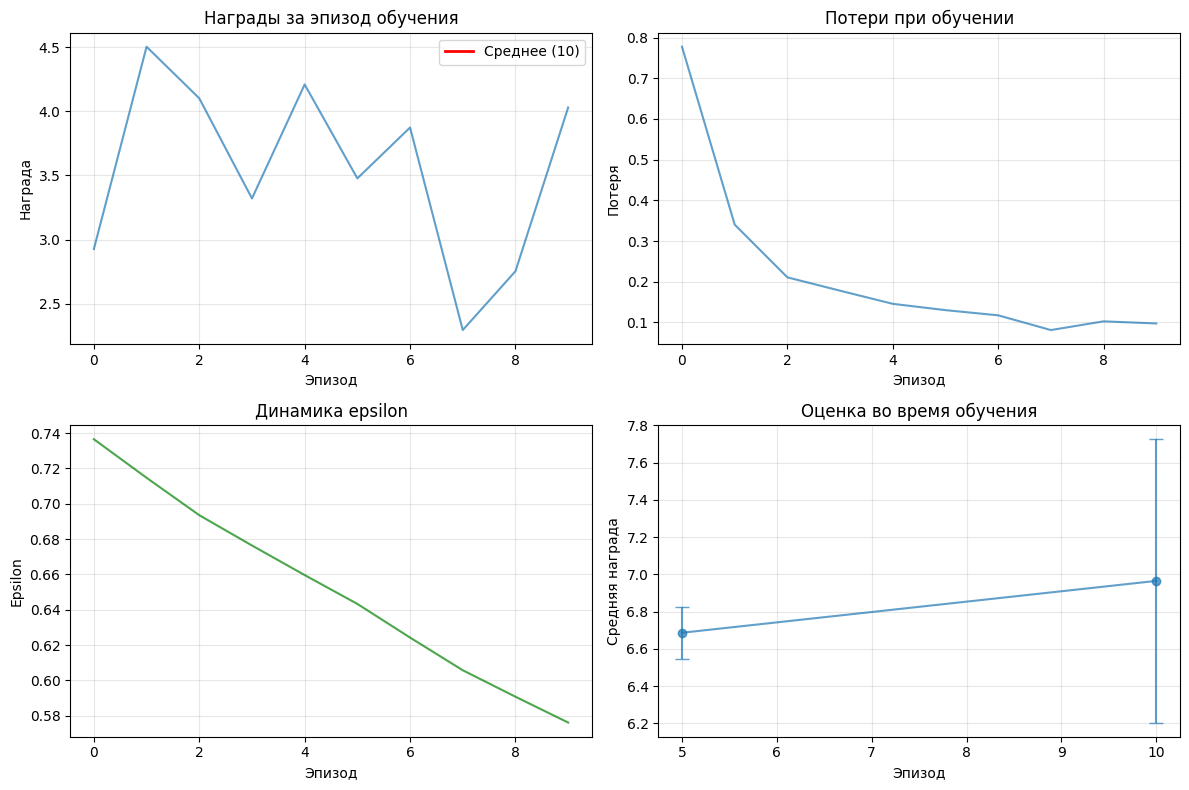


БАЗОВЫЕ ЭКСПЕРИМЕНТЫ ЗАВЕРШЕНЫ!


In [11]:
# Импорт ExperimentRunner для базовых экспериментов
from src.evaluation.experiment_runner import ExperimentRunner

print("\n" + "="*50)
print("5. БАЗОВЫЕ ЭКСПЕРИМЕНТЫ ПО ВАЛИДАЦИИ")
print("="*50)

# Создание runner
experiment_runner = ExperimentRunner(trainer, env)

# Запуск обучения на небольшом количестве эпизодов для проверки
print("\nЗапуск обучения на 10 эпизодов (для проверки)...")
training_results = experiment_runner.run_training_experiment(
    n_episodes=10,  # Для быстрого теста
    eval_interval=5
)

# Визуализация прогресса
print("\nВизуализация прогресса обучения...")
experiment_runner.plot_training_progress()

print("\n" + "="*50)
print("БАЗОВЫЕ ЭКСПЕРИМЕНТЫ ЗАВЕРШЕНЫ!")
print("="*50)

## 7. Сохранение моделей

После обучения можно сохранить модели для дальнейшего использования.

In [12]:
# Сохранение DQN агента
os.makedirs('../data/models', exist_ok=True)
trainer.save_checkpoint('../data/models/dqn_agent_checkpoint.pth')

print("Модели сохранены:")
print("  - DeepFM+SVD++: data/models/deepfm_svdplusplus_best.pth")
print("  - DQN Agent: data/models/dqn_agent_checkpoint.pth")

Чекпоинт сохранен: ../data/models/dqn_agent_checkpoint.pth
Модели сохранены:
  - DeepFM+SVD++: data/models/deepfm_svdplusplus_best.pth
  - DQN Agent: data/models/dqn_agent_checkpoint.pth
